Second try for getting the plots nice and fitted


In [3]:
import pandas as pd 
import math 
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [4]:
df_LG_lake=pd.read_excel('Lab_tests_results.xlsx', sheet_name='LG_lake')

df_LG_spring=pd.read_excel('Lab_tests_results.xlsx', sheet_name='LG_spring')

df_S3=pd.read_excel('Lab_tests_results.xlsx', sheet_name='S3')

df_S4=pd.read_excel('Lab_tests_results.xlsx', sheet_name='S4')

In [5]:
def mean_of_repeats(df, title1='Fine', title2='Medium', title3='Coarse'): 

    'dataframe input'
    'columns for which you want to summarise'

    titles=np.array([title1,title2,title3])

    for i in titles:
        I=f'{i}_R1'
        II=f'{i}_R2'
        III=f'{i}_R3'

        df[f'{i}_mean']=df[[I,II,III]].mean(axis=1)


    return df

In [6]:
mean_of_repeats(df_LG_lake, title1='Fine', title2='Medium', title3='Coarse')
mean_of_repeats(df_LG_spring, title1='Fine', title2='Medium', title3='Coarse')
mean_of_repeats(df_S3, title1='Fine', title2='Medium', title3='Coarse')
mean_of_repeats(df_S4, title1='Fine', title2='Medium', title3='Coarse')

,Time_(min),Fine_R1,Fine_R2,Fine_R3,Medium_R1,Medium_R2,Medium_R3,Coarse_R1,Coarse_R2,Coarse_R3,Fine_mean,Medium_mean,Coarse_mean
0,0.0,2.61,2.65,2.65,2.61,2.65,2.65,2.61,2.65,2.65,2.636667,2.636667,2.636667
1,0.5,4.37,4.20,4.12,4.33,3.57,3.95,4.03,2.91,3.32,4.230000,3.950000,3.420000
2,1.0,5.31,4.81,4.56,5.35,4.34,4.56,4.91,4.45,4.07,4.893333,4.750000,4.476667
3,1.5,5.71,5.10,4.92,5.66,4.75,4.91,5.40,4.69,4.41,5.243333,5.106667,4.833333
4,2.0,5.90,5.47,5.25,5.87,5.08,5.14,5.62,4.95,4.66,5.540000,5.363333,5.076667
5,2.5,6.08,5.71,5.45,6.04,5.33,5.34,5.90,5.17,4.87,5.746667,5.570000,5.313333
6,3.0,6.21,5.83,5.62,6.12,5.54,5.54,5.96,5.35,5.08,5.886667,5.733333,5.463333
7,3.5,6.29,5.96,5.79,6.21,5.68,5.71,6.08,5.50,5.25,6.013333,5.866667,5.610000
8,4.0,6.37,6.08,5.91,6.29,5.83,5.80,6.16,5.62,5.41,6.120000,5.973333,5.730000
9,4.5,6.46,6.16,6.00,6.37,5.92,5.91,6.25,5.74,5.54,6.206667,6.066667,5.843333


In [21]:
def plot_repeats_mean_loc_size(df, size='Fine', loc='LG lake'):
    """goal; plot all repeat measurements and fit a model to it and to the mean"""

    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c','#dede00']
    plt.figure(figsize=[16,10])
    plt.scatter(df['Time_(min)'], df[f'{size}_R1'], color=CB_color_cycle[0], s=25, marker='x', label="Repeat 1")
    plt.scatter(df['Time_(min)'], df[f'{size}_R2'], color=CB_color_cycle[1], s=25, marker='>', label="Repeat 2")
    plt.scatter(df['Time_(min)'], df[f'{size}_R3'], color=CB_color_cycle[2], s=25, marker='d', label="Repeat 3")
    plt.scatter(df['Time_(min)'], df[f'{size}_mean'], color=CB_color_cycle[3], s=25, label="Mean")

    plt.axhline(3, color=CB_color_cycle[4], linestyle='--', label='Expected Fe barrier')
    plt.axhline(7, color=CB_color_cycle[5], linestyle='-.', label='neutral pH')

    plt.xlabel('Time (minutes)')
    plt.ylabel('pH')
    plt.legend(loc='center right', bbox_to_anchor=(1.2,0.1))
    plt.grid()
    plt.savefig(f'images_new/{loc} at measurements and mean for grainsize {size}.png', bbox_inches='tight', dpi=300)

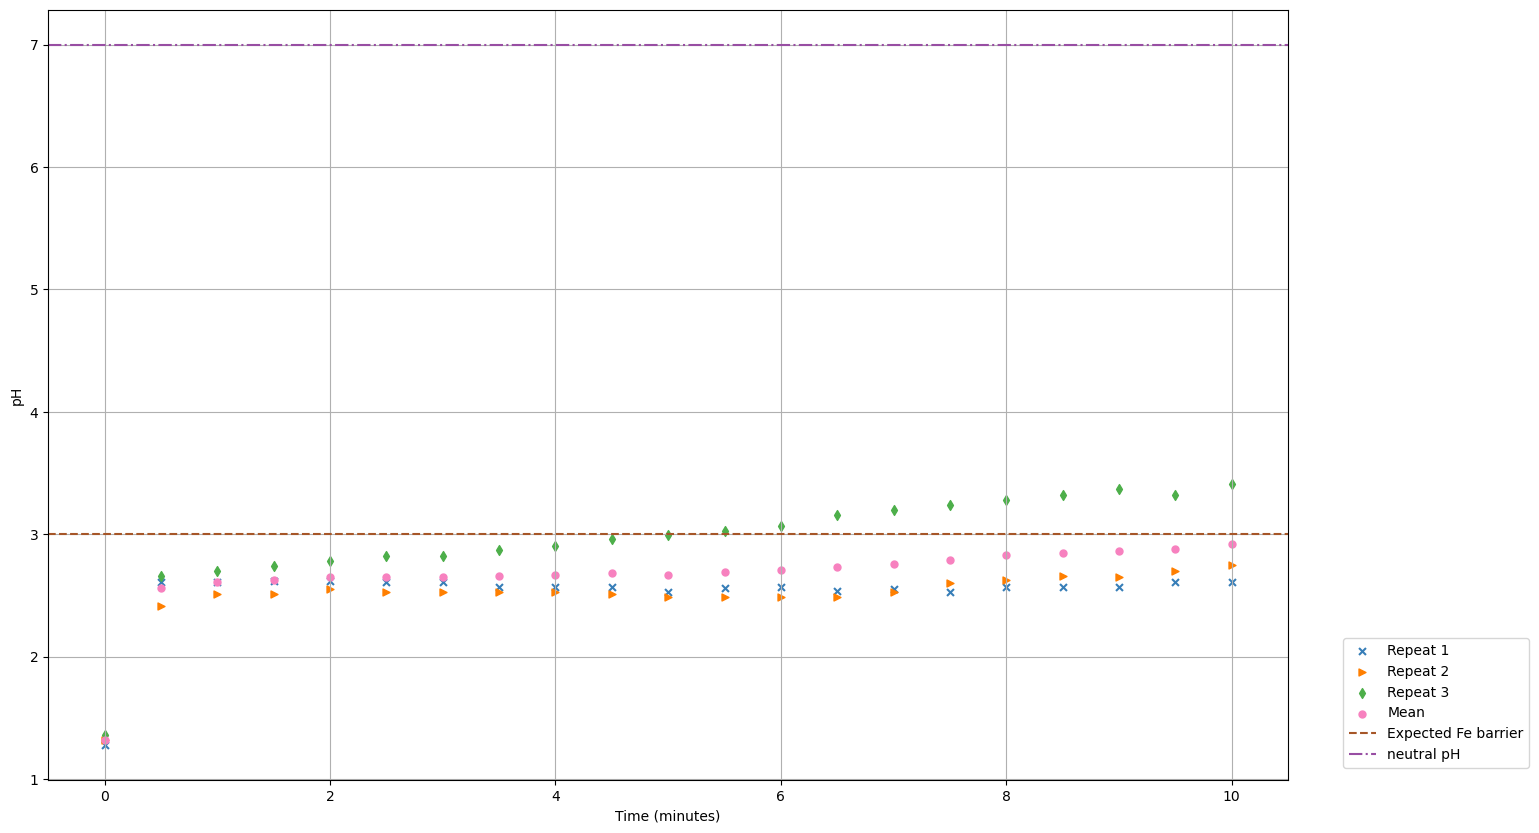

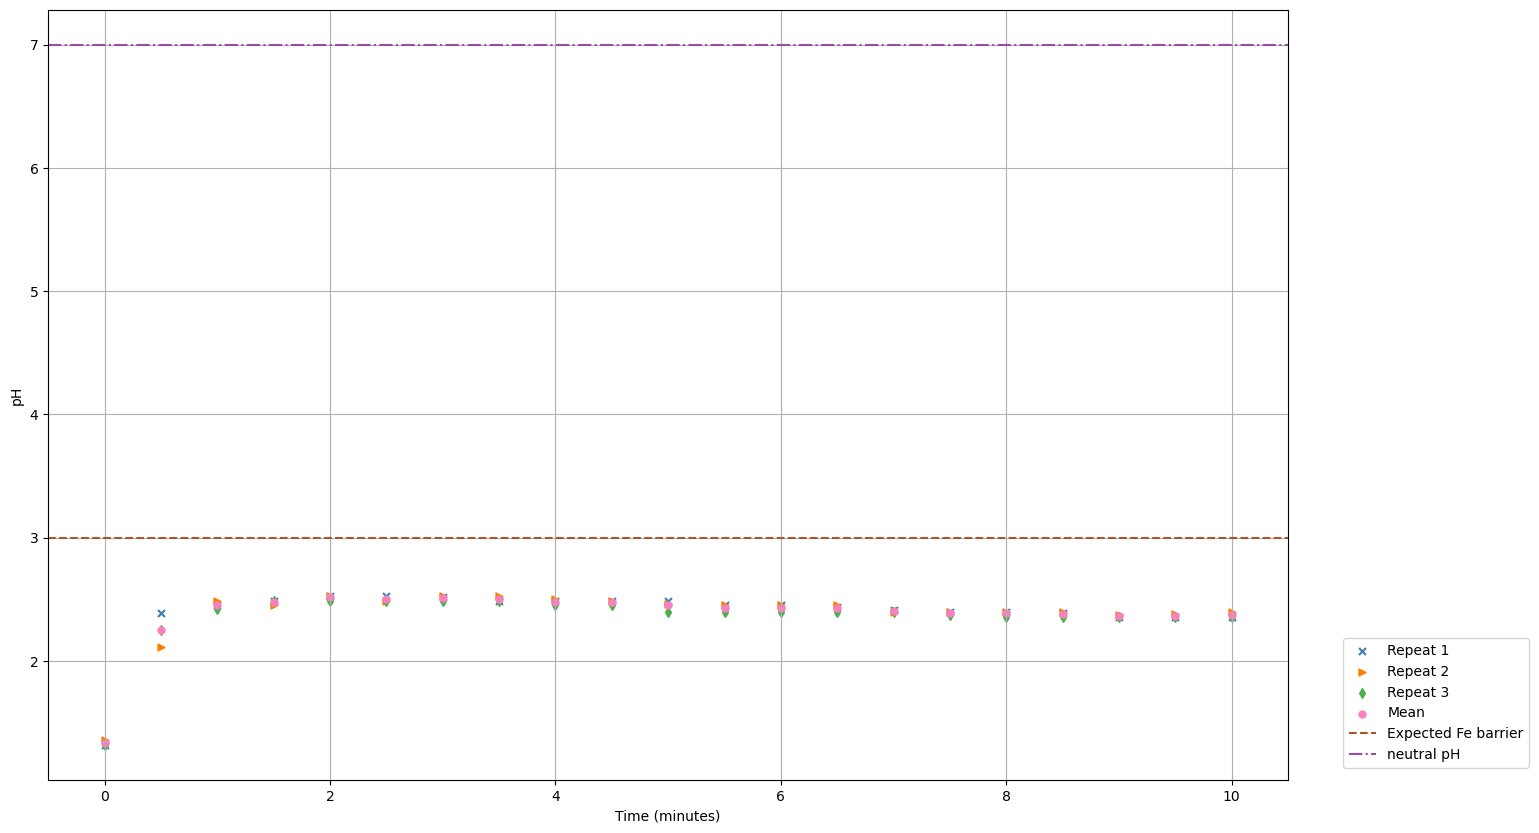

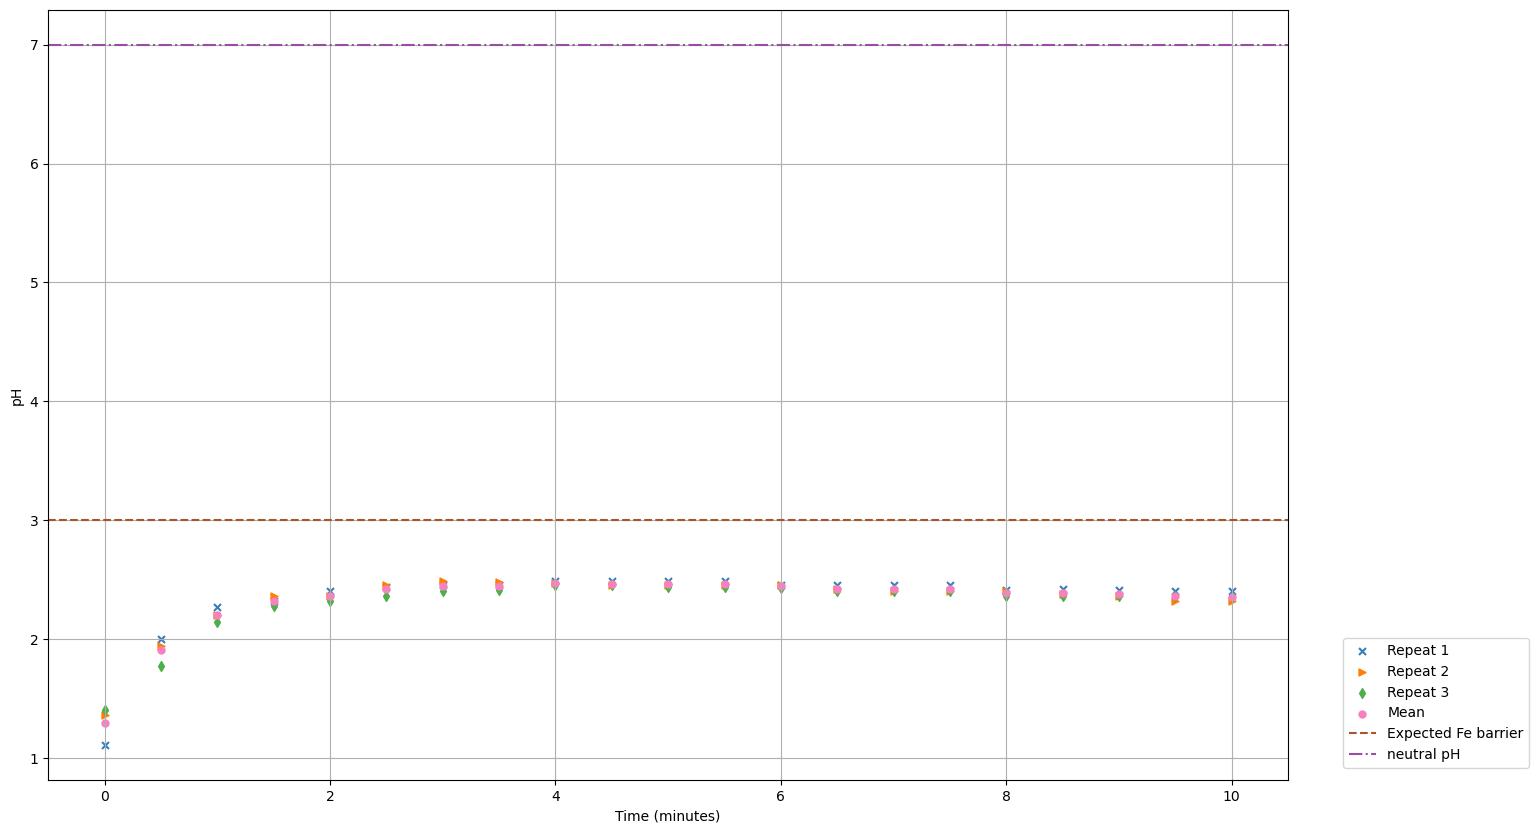

In [22]:
plot_repeats_mean_loc_size(df_LG_lake, size='Fine', loc='LG lake')
plot_repeats_mean_loc_size(df_LG_lake, size='Medium', loc='LG lake')
plot_repeats_mean_loc_size(df_LG_lake, size='Coarse', loc='LG lake')

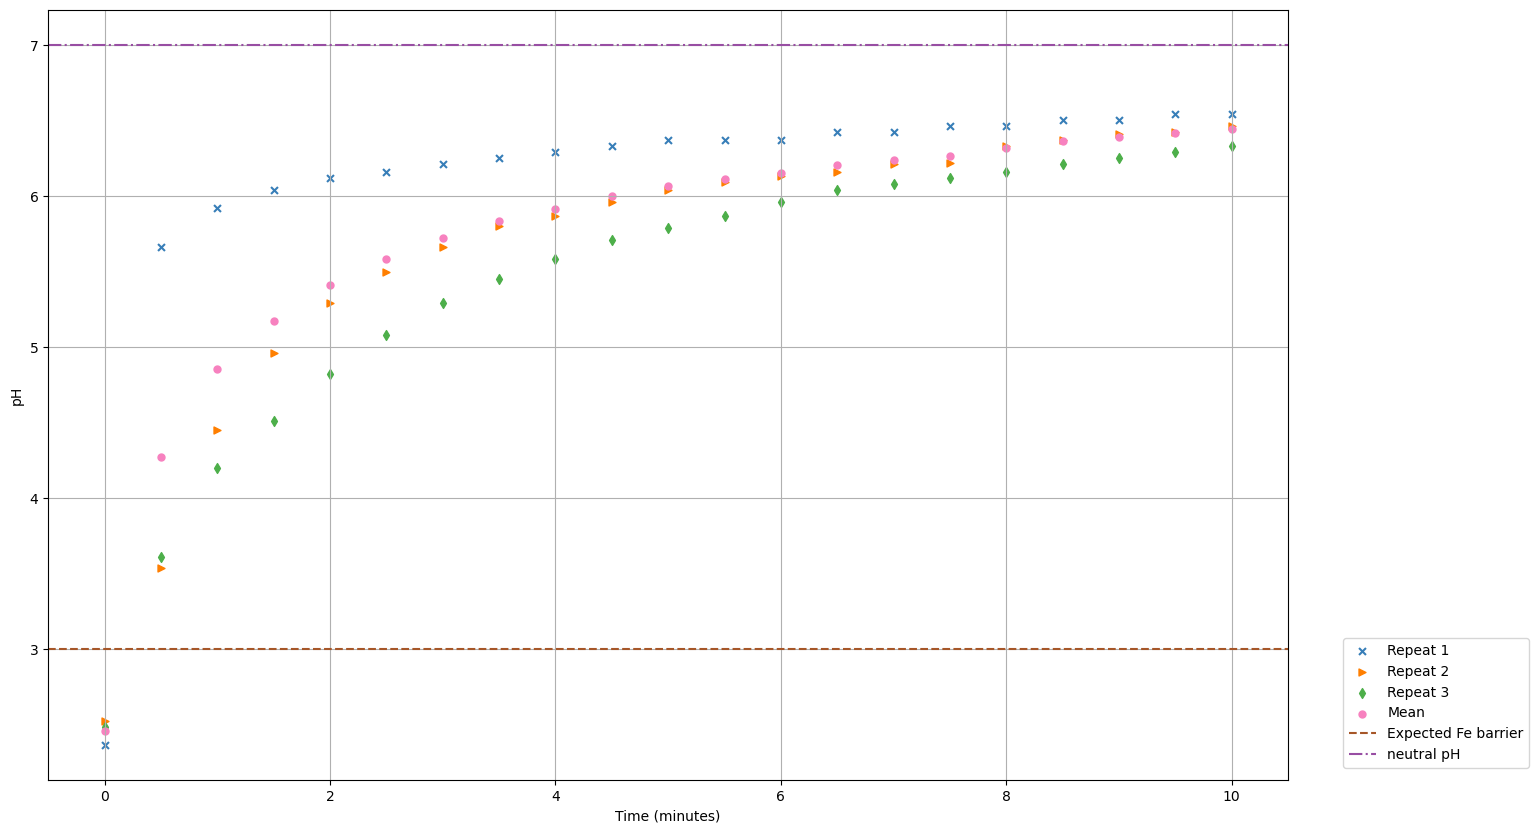

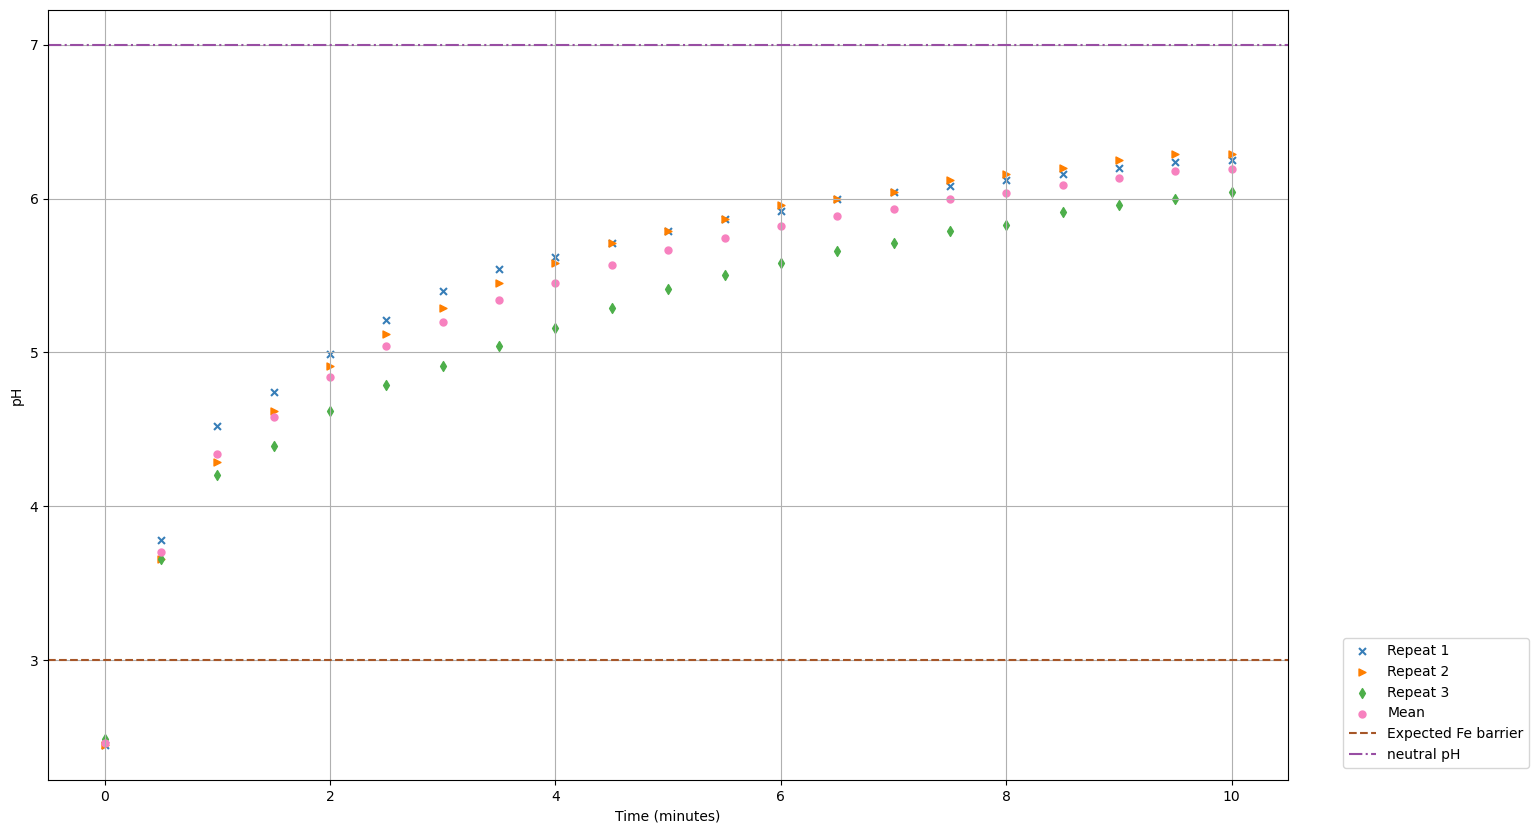

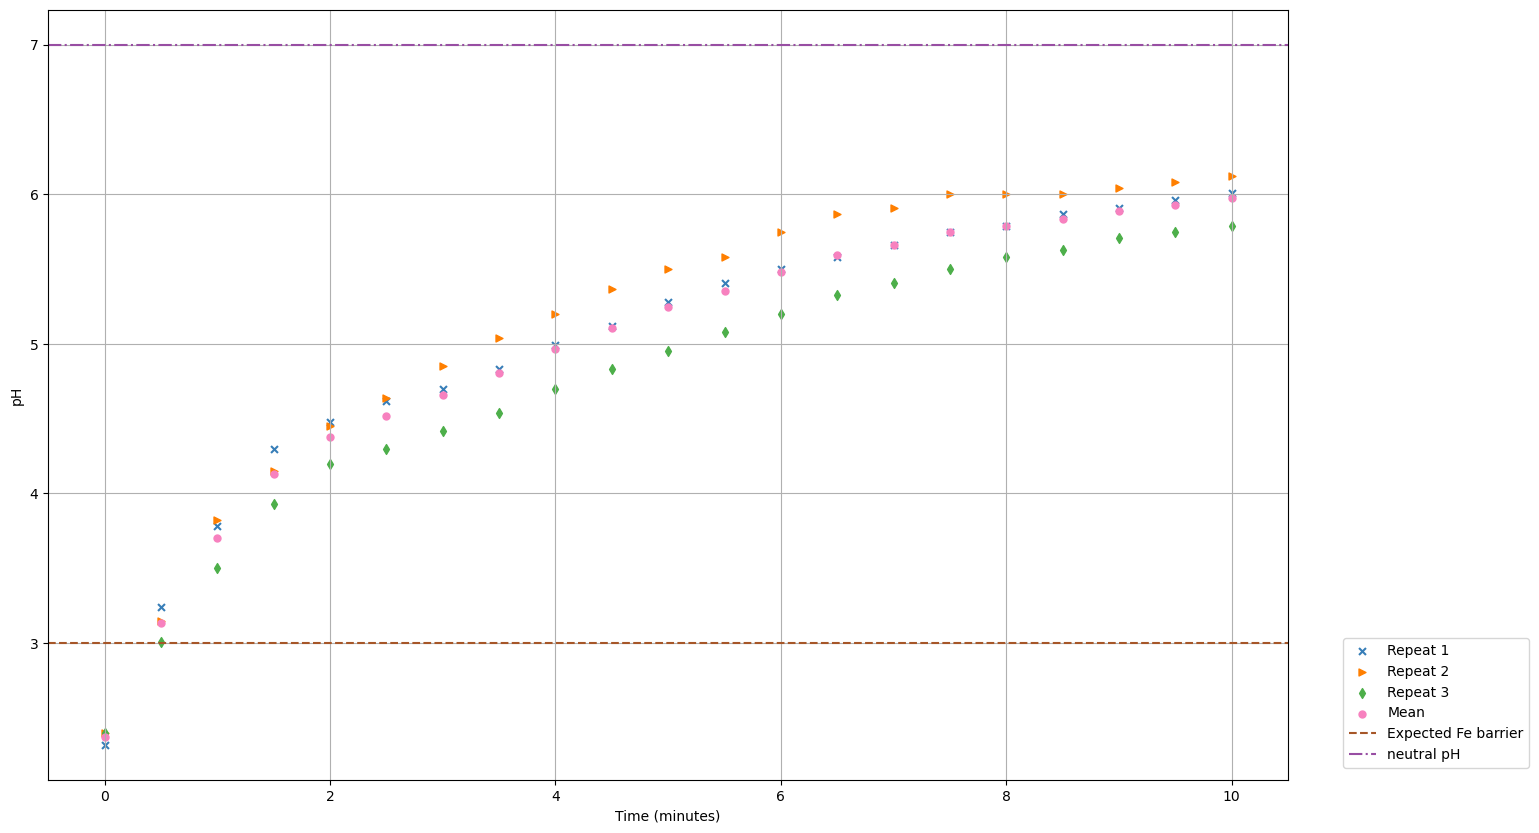

In [23]:
plot_repeats_mean_loc_size(df_LG_spring, size='Fine', loc='LG spring')
plot_repeats_mean_loc_size(df_LG_spring, size='Medium', loc='LG spring')
plot_repeats_mean_loc_size(df_LG_spring, size='Coarse', loc='LG spring')

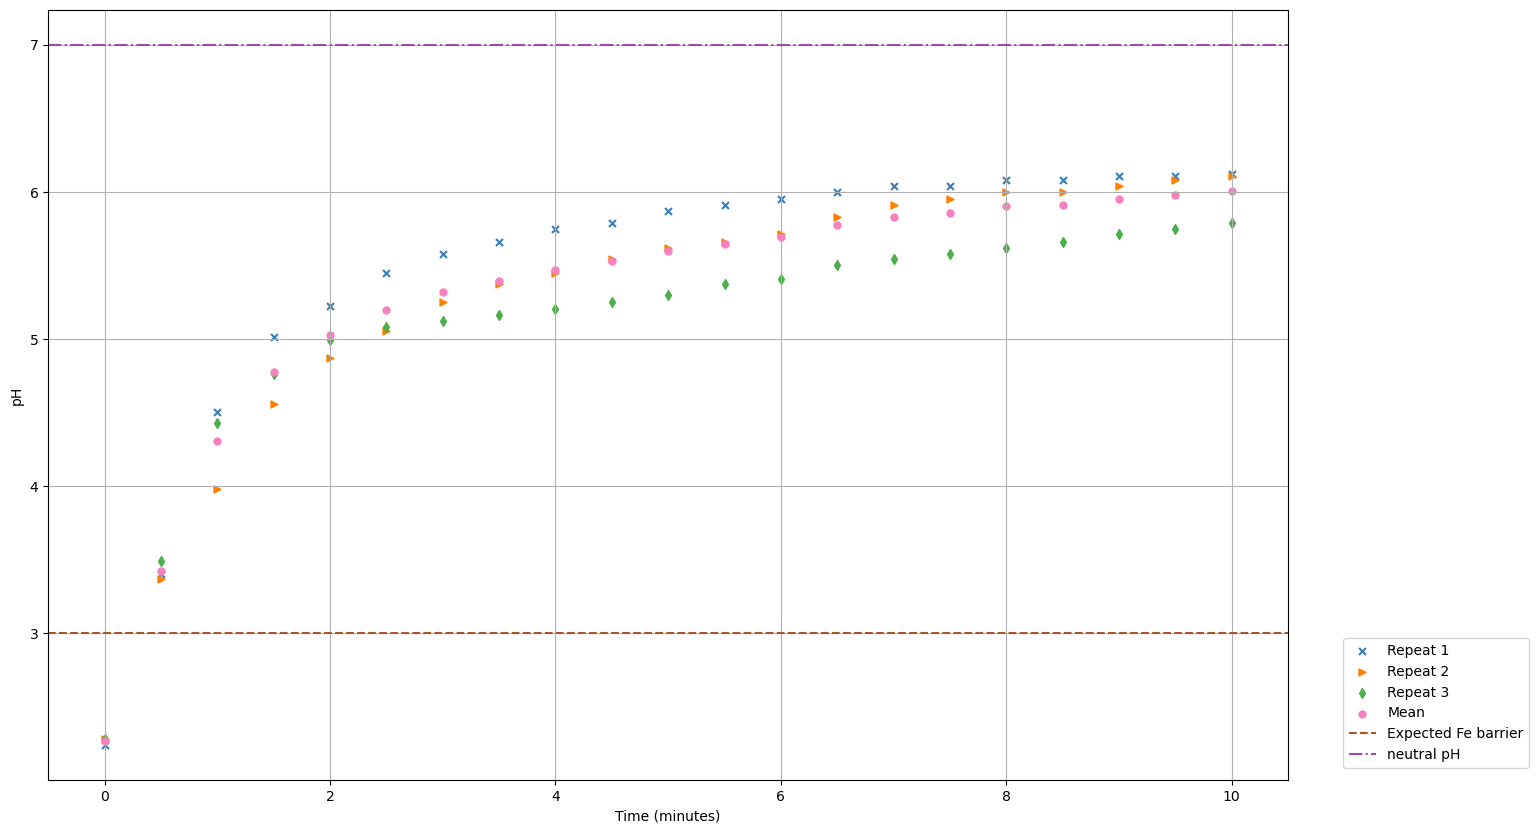

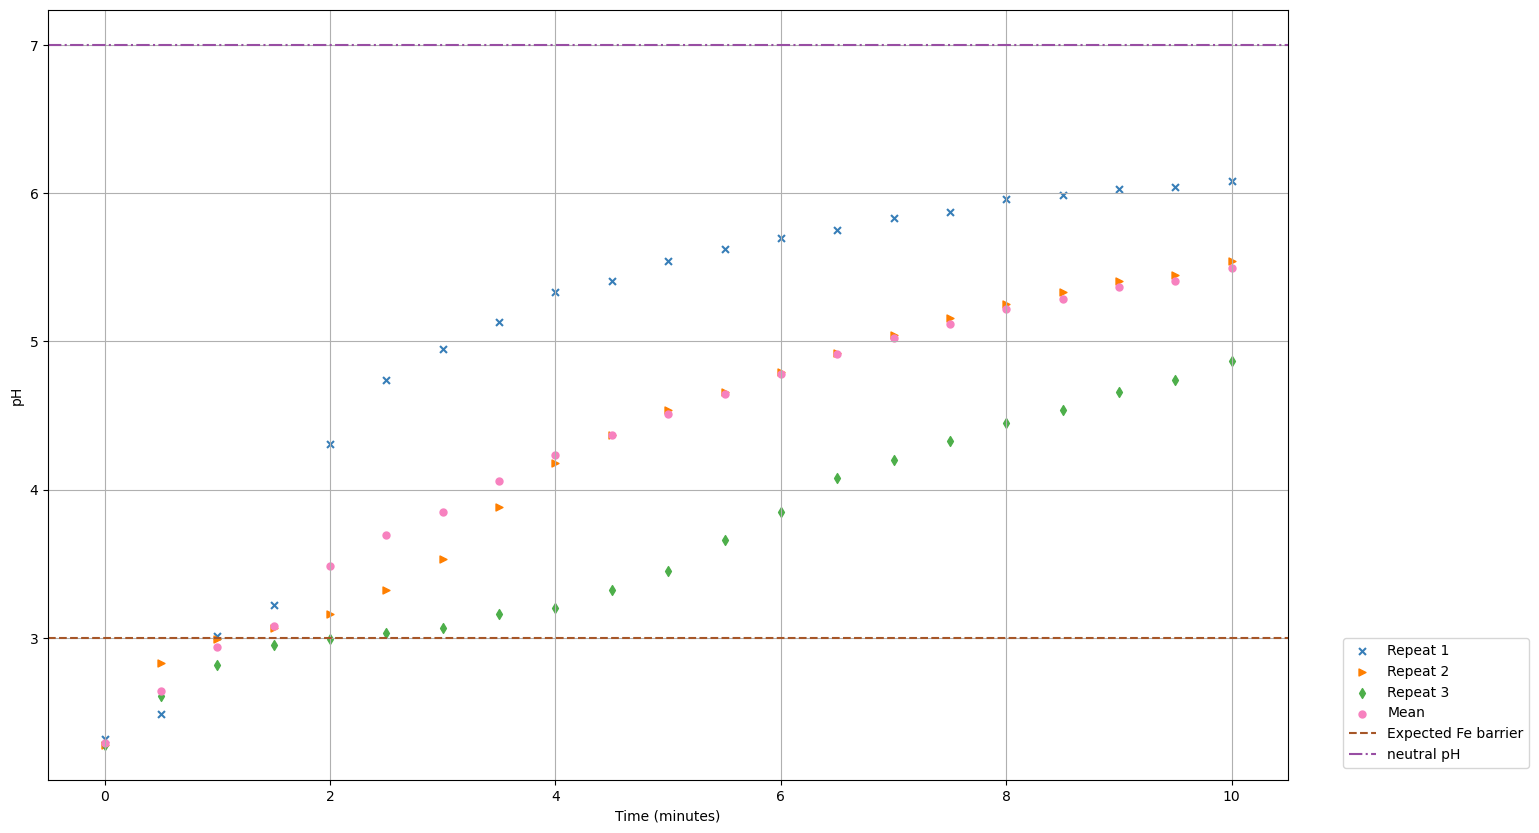

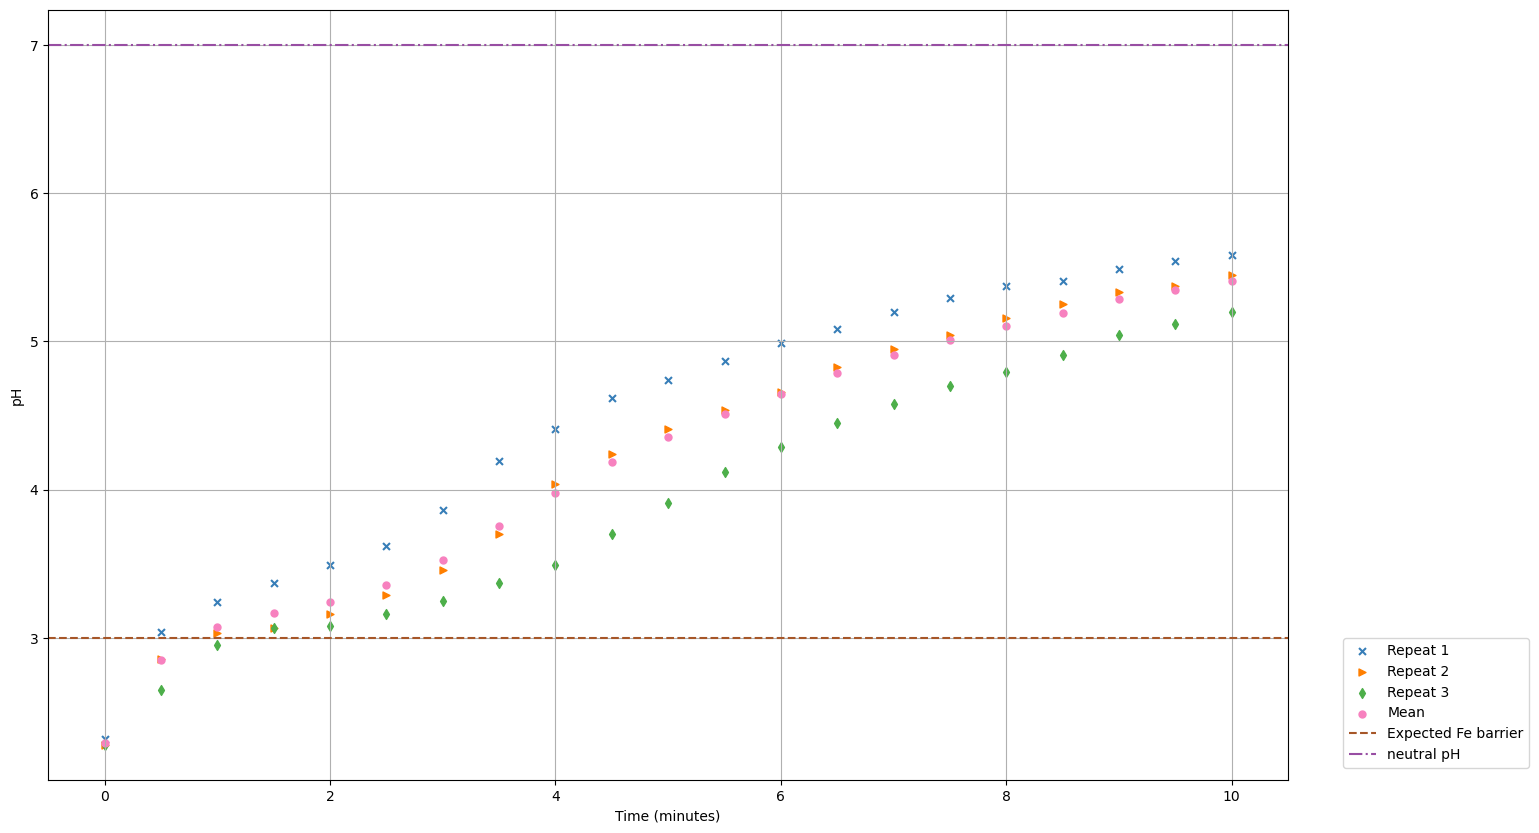

In [24]:
plot_repeats_mean_loc_size(df_S3, size='Fine', loc='Covica S3')
plot_repeats_mean_loc_size(df_S3, size='Medium', loc='Covica S3')
plot_repeats_mean_loc_size(df_S3, size='Coarse', loc='Covica S3')

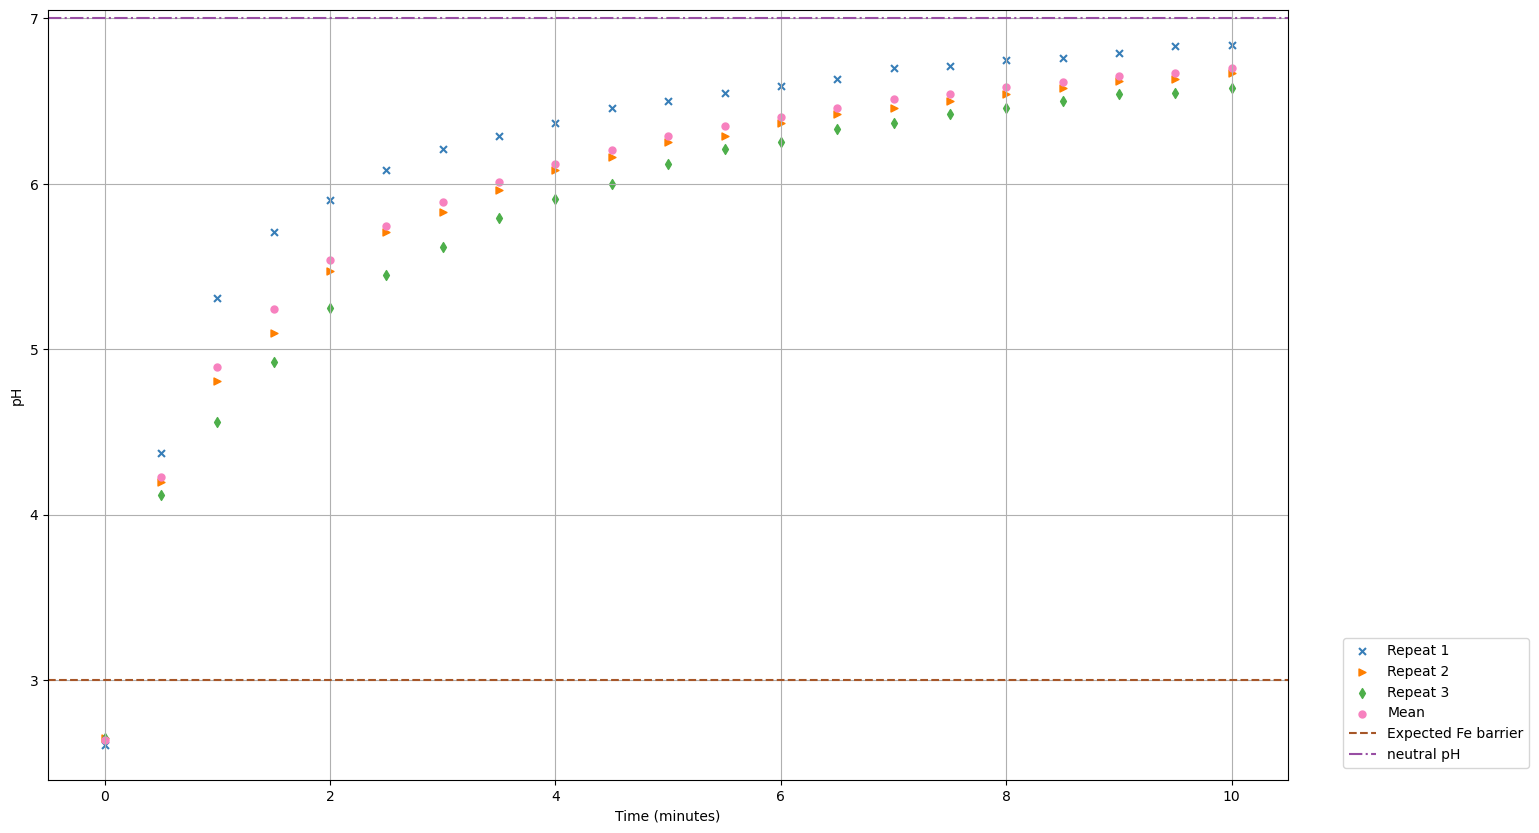

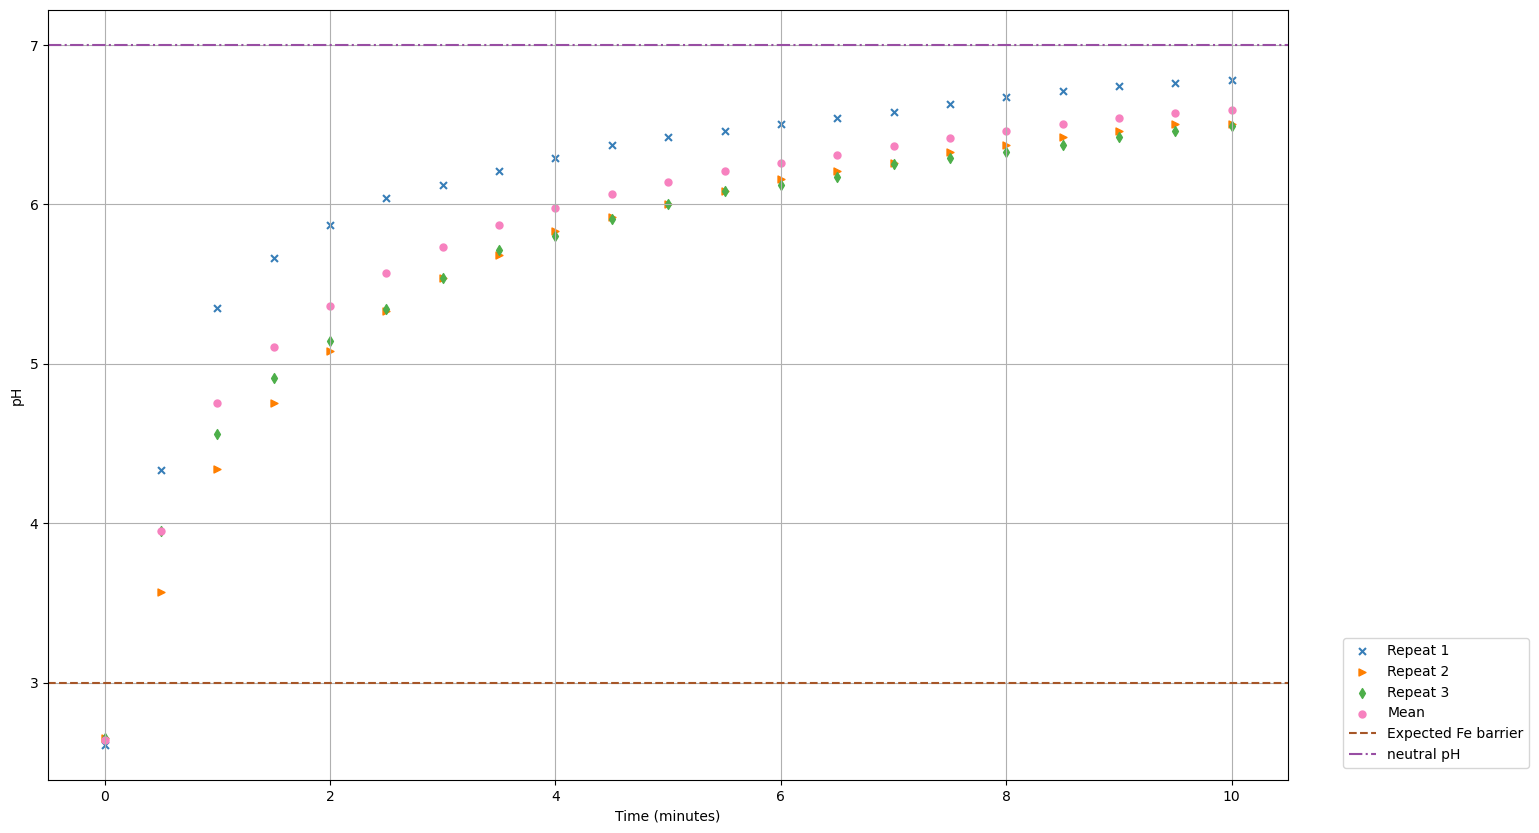

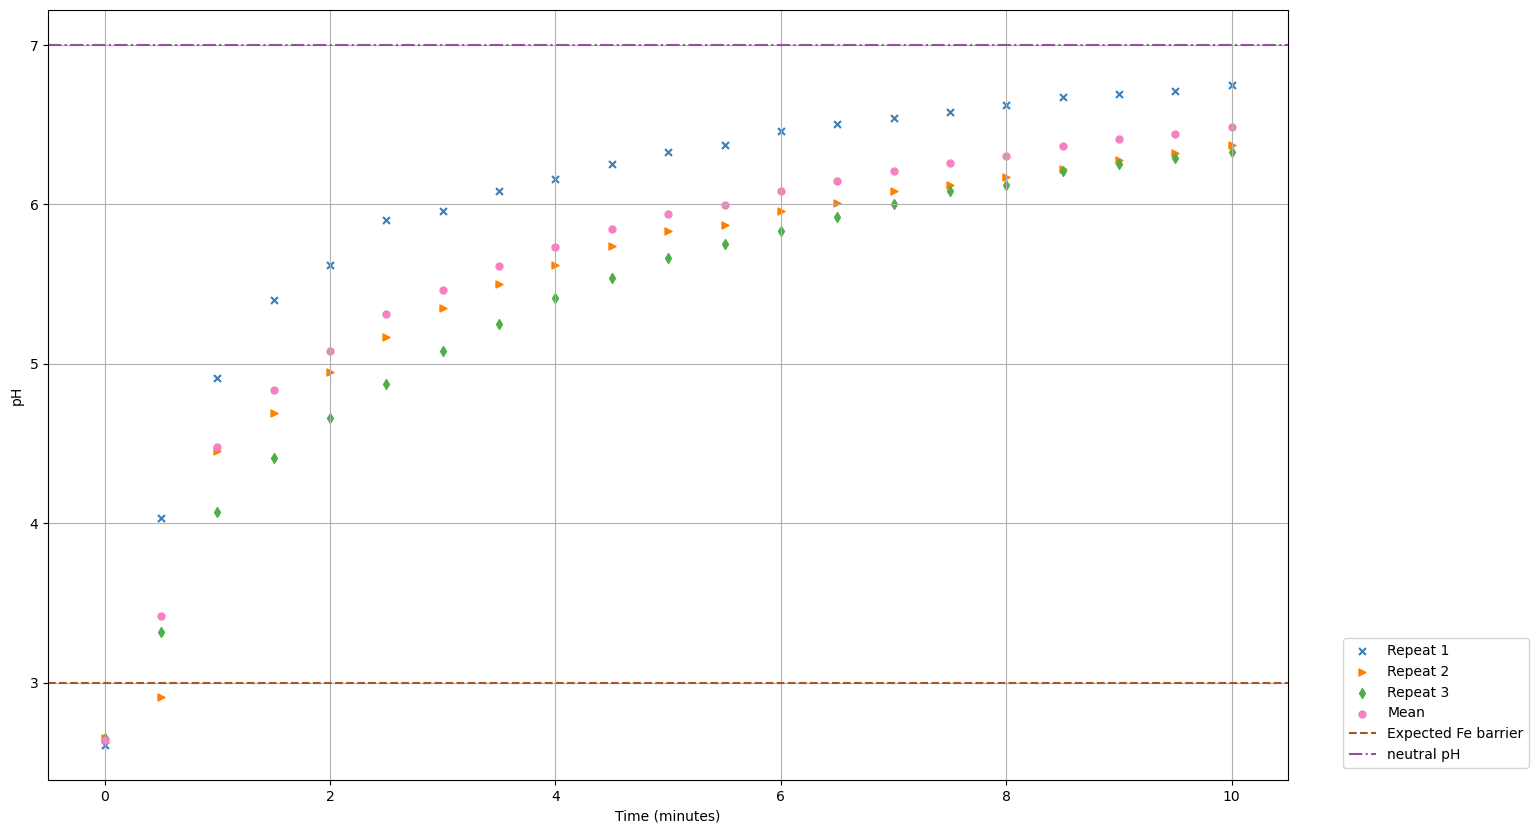

In [25]:
plot_repeats_mean_loc_size(df_S4, size='Fine', loc='Covica S4')
plot_repeats_mean_loc_size(df_S4, size='Medium', loc='Covica S4')
plot_repeats_mean_loc_size(df_S4, size='Coarse', loc='Covica S4')

In [26]:
def exp_model(t, pH0, pH_eq, k):
    return pH0 + (pH_eq - pH0) * (1 - np.exp(-k * t))


def plot_modelfit(df, size='Fine', color='r'):
    
    df = df.sort_values('Time_(min)')

    t = df['Time_(min)'].values
    y = df[f'{size}_mean'].values

    pH0 = y[0]
    pH_eq = y[-1]

    def model(t, k):
        return exp_model(t, pH0, pH_eq, k)
    
    popt, _ = curve_fit(model, t, y, p0=[0.7])

    k = popt[0]

    # smooth curve
    t_fit = np.linspace(t.min(), t.max(), 500)
    y_fit = model(t_fit, k)

    eq_label = (rf"$pH(t) = {pH0:.2f} + ({pH_eq:.2f}-{pH0:.2f})(1 - e^{{-{k:.3f}t}})$")

    plt.plot(t_fit, y_fit, color=color, lw=2, label=eq_label)



In [27]:
def plot_repeats_mean_loc_size_model_fit(df, loca='LG lake'):
    """all mean grains sizes and modelfit for one location"""

    plt.figure(figsize=[16,10])
    CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c','#dede00']

    plt.scatter(df['Time_(min)'], df['Fine_mean'], color=CB_color_cycle[0], s=25, marker='x', label="Fine")
    plt.scatter(df['Time_(min)'], df['Medium_mean'], color=CB_color_cycle[1], s=25, marker='o', label="Medium")
    plt.scatter(df['Time_(min)'], df['Coarse_mean'], color=CB_color_cycle[2], s=25, marker='d', label="Coarse")

    plot_modelfit(df, size='Fine', color=CB_color_cycle[5])
    plot_modelfit(df, size='Medium', color=CB_color_cycle[6])
    plot_modelfit(df, size='Coarse', color=CB_color_cycle[7])

    plt.axhline(3, color=CB_color_cycle[3], linestyle='--', label='Expected Fe barrier')
    plt.axhline(7, color=CB_color_cycle[4], linestyle='--', label='neutral pH')

    plt.xlabel('Time (minutes)')
    plt.ylabel('pH')
    plt.legend(loc='center right', bbox_to_anchor=(1.3,0.1))
    plt.grid()
    plt.savefig(f'images_new/{loca} mean grainsizes and model .png', bbox_inches='tight', dpi=300)

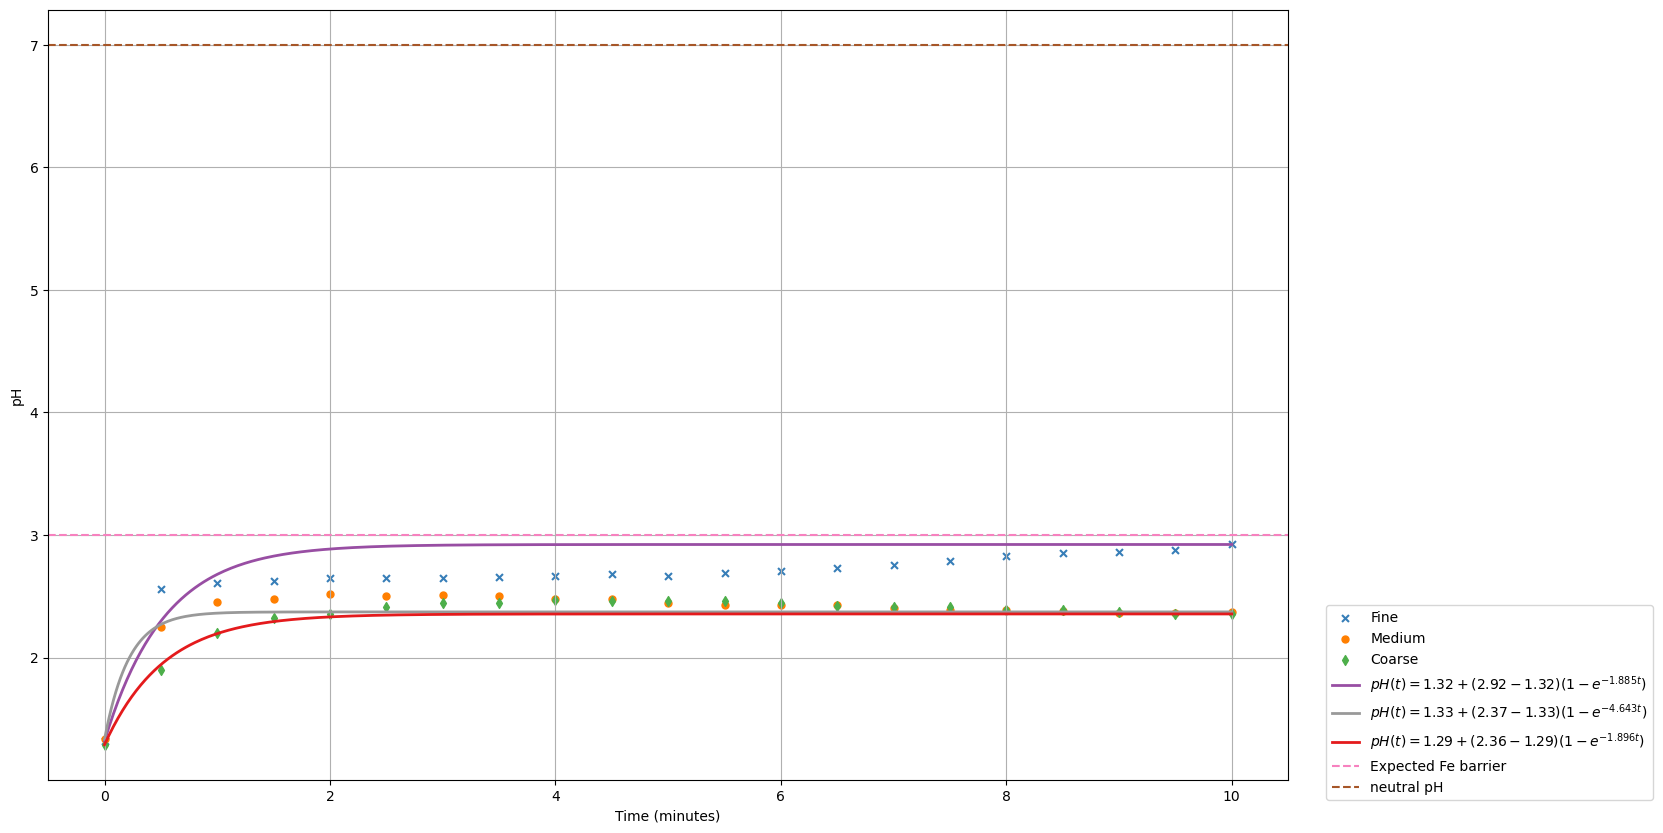

In [28]:
plot_repeats_mean_loc_size_model_fit(df_LG_lake,  loca='LG lake')

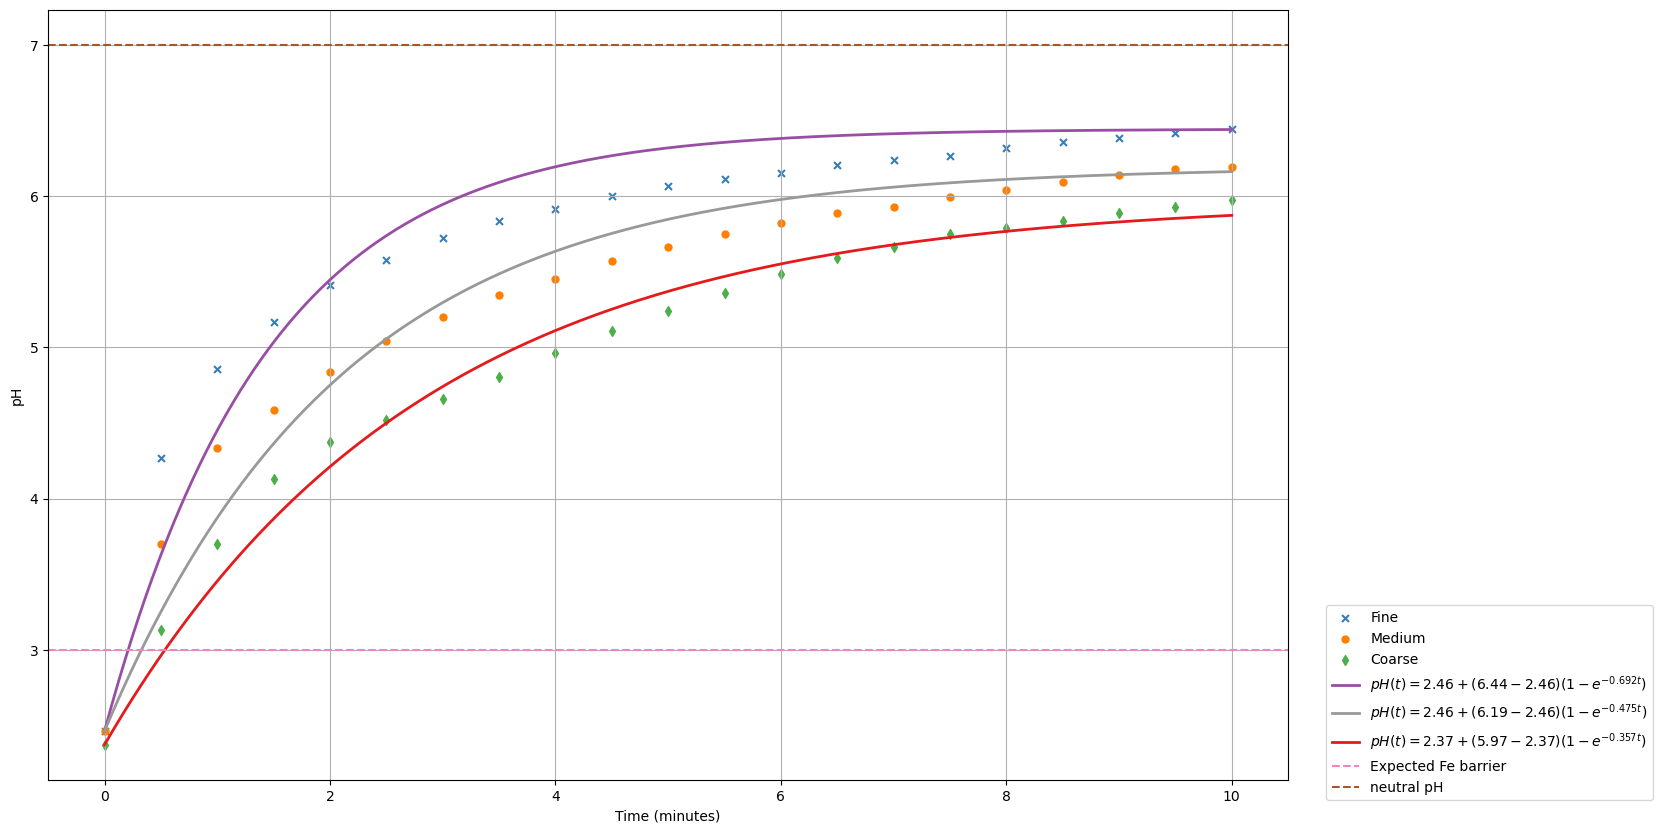

In [29]:
plot_repeats_mean_loc_size_model_fit(df_LG_spring,  loca='LG spring')

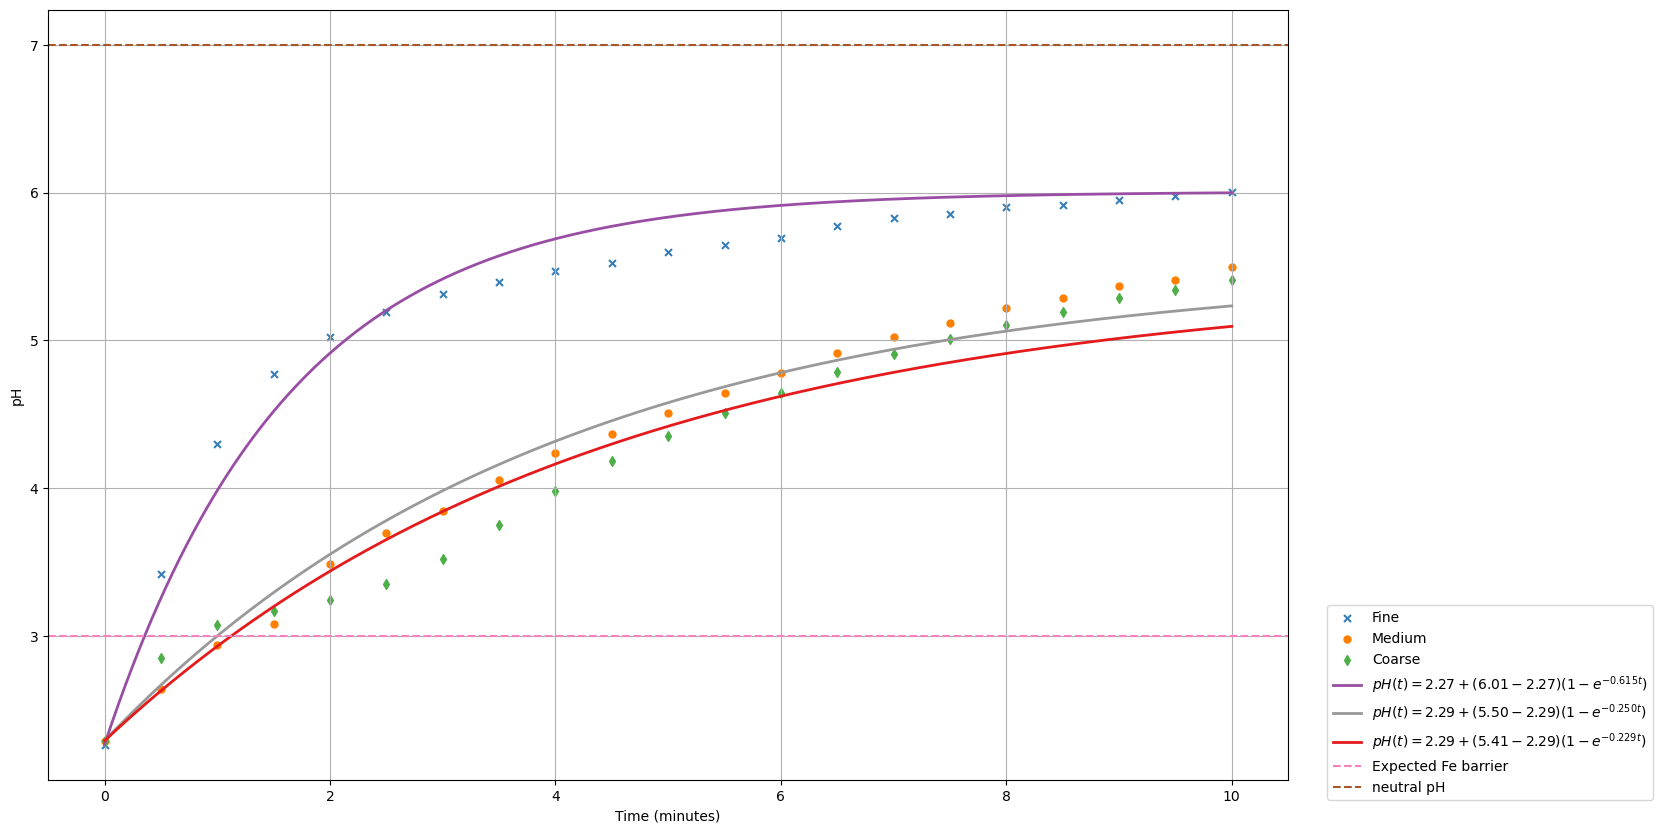

In [30]:
plot_repeats_mean_loc_size_model_fit(df_S3,  loca='Covica S3')

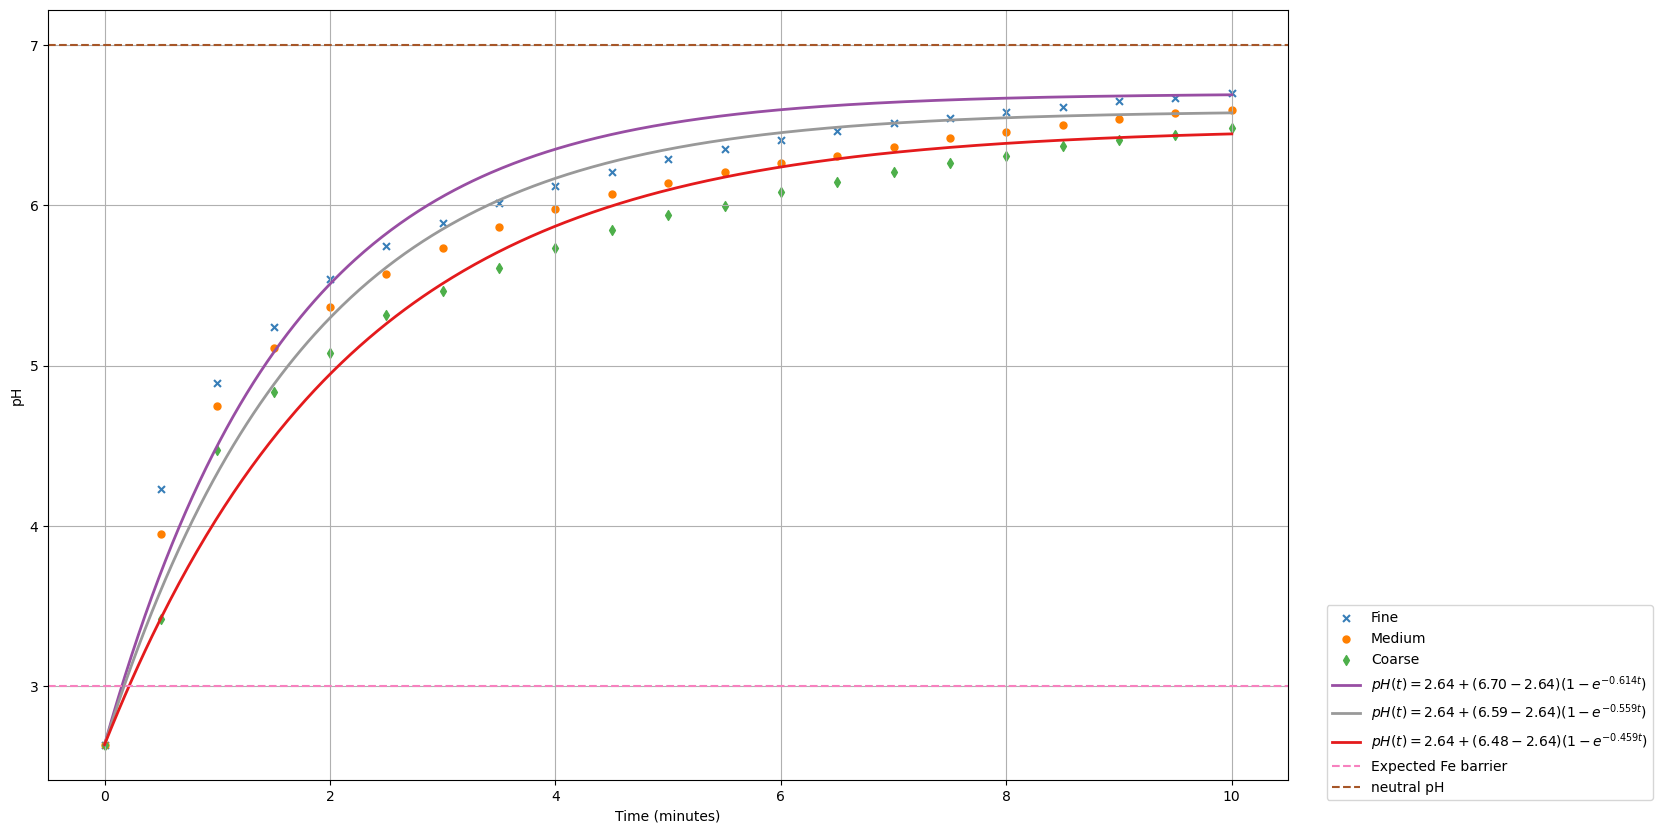

In [31]:
plot_repeats_mean_loc_size_model_fit(df_S4,  loca='Covica S4')

In [32]:
df_XRF_S3=pd.read_excel('XRF.xlsx', sheet_name='S3')
df_XRF_lake=pd.read_excel('XRF.xlsx', sheet_name='LG_lake')
df_XRF_S4=pd.read_excel('XRF.xlsx', sheet_name='S4')
df_XRF_spring=pd.read_excel('XRF.xlsx', sheet_name='LG_spring')

In [33]:
df_XRF_S3

,Sample,Ag,As,Au,Bal,Bi,Cd,Co,Cr,Cu,...,Th,Ti,U,V,W,Y,Zn,Zr,Unnamed: 34,Unnamed: 35
0,Covica_S3_0.63mm_R1,19.5319 ± 17.5366,11.5172 ± 2.0684,<LOD=5.7810,668635.2500 ± 2032.9926,<LOD=2.4167,<LOD=12.9894,<LOD=46.8741,15.7167 ± 11.0061,36.7713 ± 5.2765,...,<LOD=2.4447,313.4851 ± 45.2566,17.4960 ± 3.6471,<LOD=17.2133,<LOD=0.0000,1.3748 ± 0.8372,53.2553 ± 3.9041,8.3682 ± 2.5751,317448.5312 ± 849.2877,1498.1951 ± 133.2179
1,Covica_S3_1.18mm_R1,27.3972 ± 24.5981,23.6667 ± 2.5295,5.2439 ± 4.3447,632002.4375 ± 2133.5732,<LOD=2.2908,<LOD=13.5959,<LOD=55.4308,<LOD=11.3849,57.2231 ± 6.1117,...,3.1583 ± 1.6811,48.0926 ± 20.7173,22.0087 ± 4.1222,25.6566 ± 5.9074,<LOD=0.0000,<LOD=1.2289,86.1066 ± 4.8348,<LOD=4.2927,350118.5625 ± 412.3220,526.0566 ± 50.2956
2,Covica_S3_1.18mm_R1,26.3474 ± 23.1777,23.6752 ± 2.5383,<LOD=5.9777,983762.0000 ± 265.6991,<LOD=2.6723,<LOD=12.8927,<LOD=54.7729,<LOD=62.8995,46.9436 ± 5.8061,...,<LOD=2.5545,<LOD=240.2225,18.7683 ± 3.8122,93.8810 ± 82.5332,<LOD=0.0000,<LOD=1.2154,72.1212 ± 4.4815,<LOD=5.8395,NaN,NaN
3,Covica_S3_1.18mm_R1,18.4833 ± 16.5951,23.5574 ± 2.5056,<LOD=6.0342,642077.5000 ± 2146.1267,<LOD=2.5520,<LOD=13.3462,<LOD=54.3908,19.7736 ± 10.0558,41.5116 ± 5.6120,...,<LOD=2.5154,60.2406 ± 33.2347,21.8251 ± 3.9770,18.0983 ± 9.5609,<LOD=0.0000,<LOD=1.2948,70.7176 ± 4.4541,<LOD=4.1225,341654.0938 ± 733.7383,351.0271 ± 87.6379
4,Covica_S3_1.8mm_R1,35.2383 ± 30.9985,20.6795 ± 2.4577,<LOD=6.3370,986257.5000 ± 280.9546,<LOD=2.5455,15.6390 ± 8.7041,<LOD=52.0513,<LOD=84.2153,56.9815 ± 6.2449,...,<LOD=2.4881,<LOD=257.5657,18.4737 ± 3.7817,<LOD=189.1918,<LOD=0.0000,<LOD=1.1533,72.2419 ± 4.6185,<LOD=4.1658,NaN,NaN
5,Covica_S3_1.8mm_R1,15.0408 ± 13.2316,22.1288 ± 2.2754,<LOD=5.5024,981746.3750 ± 265.7322,<LOD=2.3527,<LOD=12.1270,<LOD=55.7962,<LOD=68.3720,74.1719 ± 6.2164,...,<LOD=2.4957,<LOD=221.6129,14.6453 ± 3.2054,<LOD=112.1552,<LOD=0.0000,<LOD=1.0669,98.0775 ± 4.8363,<LOD=3.2631,NaN,NaN
6,Covica_S3_1.8mm_R1,39.0164 ± 35.0295,17.6508 ± 2.2254,<LOD=5.7209,638448.8750 ± 2198.4878,<LOD=2.4832,<LOD=17.6223,<LOD=46.4844,<LOD=24.9362,59.0418 ± 5.8841,...,<LOD=2.4741,<LOD=108.5315,18.6936 ± 3.7092,<LOD=17.2438,<LOD=0.0000,1.3881 ± 0.7975,64.7105 ± 4.1946,<LOD=3.9042,348620.8438 ± 899.5381,285.9116 ± 106.7861
